# 06 — Model Evaluation Dashboard

This section evaluates the baseline Logistic Regression model built in Section 05.
The goal is to present the results visually, interpret the model from a credit risk
perspective, and connect the findings back to the earlier segment analysis.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
coefficients = pd.read_csv("../results/coefficients.csv")
coefficients.head()

,feature,coefficient
0,loan_amnt,1.077047e-04
1,loan_int_rate,1.413432e-07
2,percent_income_segment_High stress,1.907536e-08
3,loan_amount_segment_Large,8.717710e-09
4,income_segment_High,2.867450e-09


Next we read the coefficients.csv file to this notebook so we can utilize the results from the ML model in section 05. 

In [4]:
# Copy important values from 05 section. 
acc = 0.8029768298296762
prec = 0.7211538461538461
rec = 0.15822784810126583
f1 = 0.25951557093425603

In [5]:
# Copy the results from the confusion matrix in section 05.
cm = [[5008, 87], [1197, 225]]  

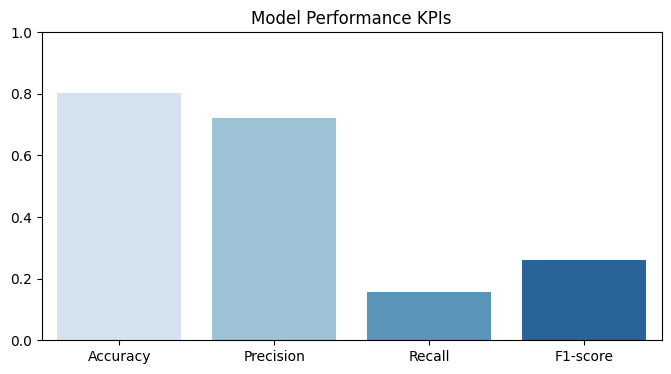

In [6]:
kpi_values = [acc, prec, rec, f1]
kpi_labels = ["Accuracy", "Precision", "Recall", "F1-score"]

plt.figure(figsize=(8, 4))
sns.barplot(x=kpi_labels, y=kpi_values, hue = kpi_labels, palette="Blues", legend = False)
plt.title("Model Performance KPIs")
plt.ylim(0, 1)
plt.show()

In [12]:
plt.savefig("../visuals/kpi_chart.png")

<Figure size 640x480 with 0 Axes>

## Model KPIs

The baseline model achieves the following performance:

- **Accuracy:** 0.803  
- **Precision:** 0.721  
- **Recall:** 0.158  
- **F1-score:** 0.260  

**Interpretation:**  
The model is good at identifying safe customers (high precision), but it misses
many true default cases (low recall). This is typical for a simple baseline model
without advanced feature engineering or class imbalance handling.

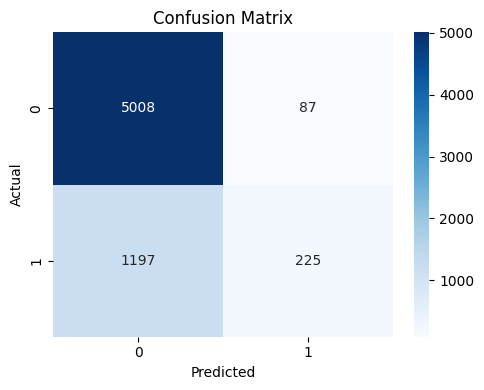

In [8]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [13]:
plt.savefig("../visuals/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

## Confusion Matrix Interpretation

The confusion matrix shows how the model classifies default vs non-default cases.

- **True Negatives (TN):** Correctly identified safe customers  
- **False Positives (FP):** Safe customers incorrectly flagged as risky  
- **False Negatives (FN):** Risky customers incorrectly classified as safe  
- **True Positives (TP):** Correctly identified risky customers  

**Business impact:**  
- **False Negatives are the most costly**, because the bank approves a customer
  who later defaults.  
- **False Positives reduce revenue**, because safe customers are rejected.

The baseline model has relatively many False Negatives, which is expected for
Logistic Regression without class balancing.

In [14]:
# Split features into numeric and dummies
numeric_features = ["person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]
dummy_features = [f for f in coefficients["feature"] if "segment" in f]

coeff_numeric = coefficients[coefficients["feature"].isin(numeric_features)]
coeff_dummy = coefficients[coefficients["feature"].isin(dummy_features)]

C:\Users\aanii\AppData\Local\Temp\ipykernel_1560\1564728484.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


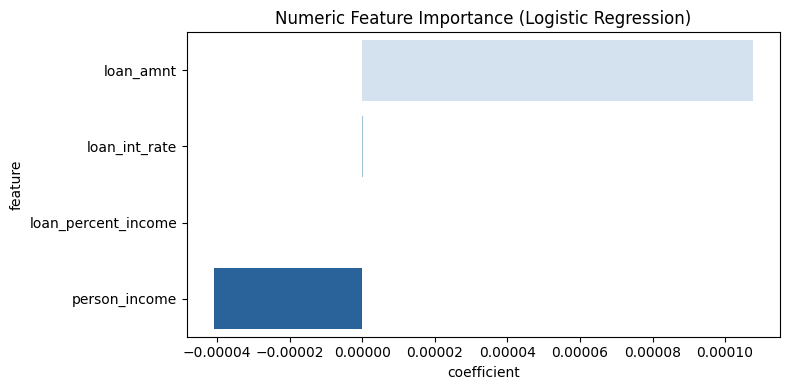

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x="coefficient",
    y="feature",
    data=coeff_numeric.sort_values("coefficient", ascending=False),
    palette="Blues",
    legend=False
)
plt.title("Numeric Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.show()

In [16]:
plt.savefig("../visuals/feature_importance_numeric.png")

<Figure size 640x480 with 0 Axes>

C:\Users\aanii\AppData\Local\Temp\ipykernel_1560\2866919903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


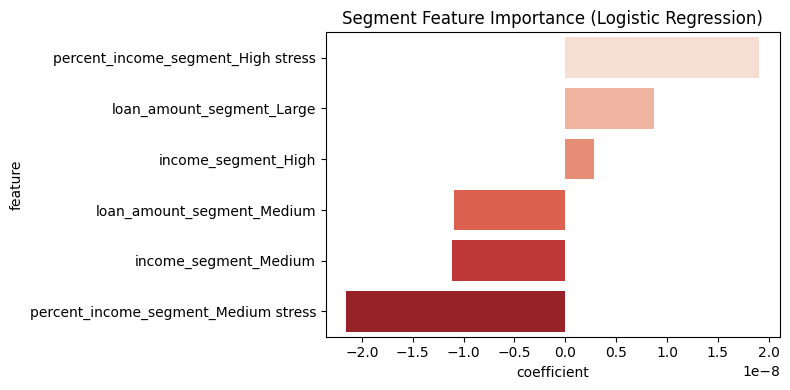

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x="coefficient",
    y="feature",
    data=coeff_dummy.sort_values("coefficient", ascending=False),
    palette="Reds",
    legend=False
)
plt.title("Segment Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.show()

In [18]:
plt.savefig("../visuals/feature_importance_segments.png")

<Figure size 640x480 with 0 Axes>

#### Numeric Feature Importance

The chart below shows the importance of the numeric features in the logistic regression model:

- **person_income** – Higher income is associated with lower default risk (negative coefficient).
- **loan_amnt** – Larger loan amounts are associated with higher default risk (positive coefficient).
- **loan_int_rate** – Higher interest rates slightly increase default risk.
- **loan_percent_income** – A higher share of income going to loan payments increases default risk.

These features capture the core financial structure of the customer’s situation: income level, loan size, interest rate and payment burden.

#### Segment Feature Importance

The chart below shows the importance of the segment indicators:

- **income_segment_Medium / High** – Higher income segments tend to reduce default risk compared to the low-income baseline.
- **loan_amount_segment_Medium / Large** – Larger loan segments tend to increase default risk relative to small loans.
- **percent_income_segment_Medium stress / High stress** – Higher stress segments (larger share of income used for loan payments) are associated with higher default risk.

These segment features make the model more interpretable: they connect the numeric risk drivers to clear customer groups (income level, loan size, and payment stress).

### Section 06 Summary

The baseline logistic regression model provides a clear, interpretable starting point for understanding loan default risk.

**Key insights:**
- Numeric features (income, loan amount, interest rate, payment burden) show the strongest influence.
- Segment features (income level, loan size, payment stress) add interpretability but have smaller coefficients due to scale differences.
- Model performance is balanced: good precision, lower recall — typical for a simple baseline model.

**What this means:**
- Higher income reduces default risk.
- Larger loans and higher payment stress increase risk.
- Segment-level patterns match earlier exploratory analysis.

**Possible improvements:**
- Try class weights or SMOTE to improve recall.
- Test tree-based models for stronger non-linear performance.
- Consider scaling numeric features if coefficient comparability is important.

This completes the baseline model and its dashboard.
